In [5]:
import pandas as pd
import pm4py

full_df = pd.read_csv(
    "../data/processed/CTB/s5_eventlog_one_block_target_features.csv"
)

sample_df = pd.read_csv(
    "../data/processed/CTB/sampled_real_eventlogs/s5_sample_30.000_eventlog_one_block_target_features.csv"
)

print("FULL")
print(
    full_df["case:concept:name"]
    .nunique()
)

print("\nSAMPLE")
print(
    sample_df["case:concept:name"]
    .nunique()
)

FULL
65996

SAMPLE
30000


,Full,Sample,diff
RMG_receive,0.181645,0.180825,0.000820
RMG_mixed,0.059933,0.060462,0.000529
RMG_delivery,0.082470,0.082791,0.000321
HO2_mixed,0.000614,0.000519,0.000095
HO2_delivery,0.002200,0.002128,0.000072
LL_delivery,0.016144,0.016204,0.000059
LL_mixed,0.007463,0.007508,0.000044
Gate In,0.324048,0.324079,0.000031
Gate Out,0.324048,0.324079,0.000031
LL_receive,0.000727,0.000702,0.000025


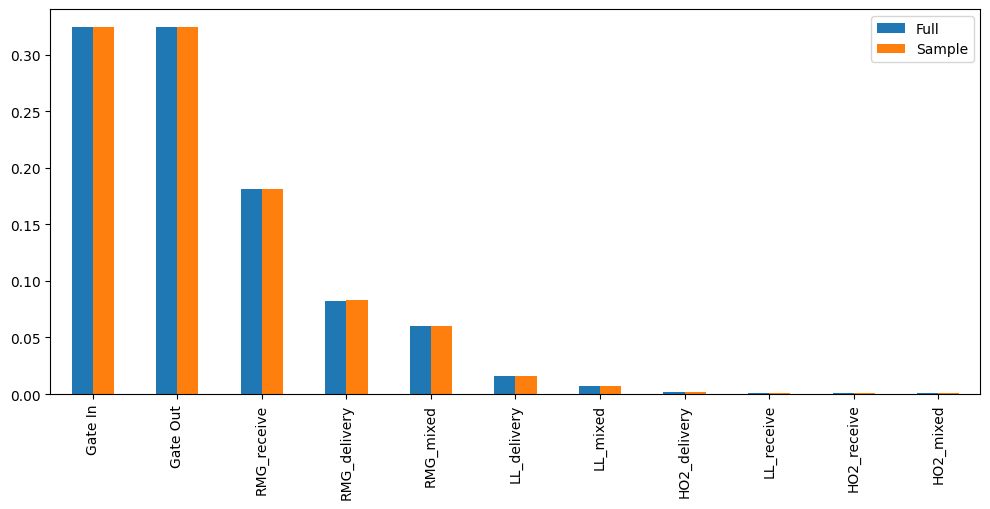

In [6]:
#2 Activity Distribution
import matplotlib.pyplot as plt

full_freq = (
    full_df["concept:name"]
    .value_counts(normalize=True)
)

sample_freq = (
    sample_df["concept:name"]
    .value_counts(normalize=True)
)

compare = pd.concat(
    [
        full_freq.rename("Full"),
        sample_freq.rename("Sample")
    ],
    axis=1
).fillna(0)

compare["diff"] = (
    compare["Full"]
    - compare["Sample"]
).abs()

display(
    compare.sort_values(
        "diff",
        ascending=False
    ).head(20)
)

compare[
    ["Full", "Sample"]
].head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.show()

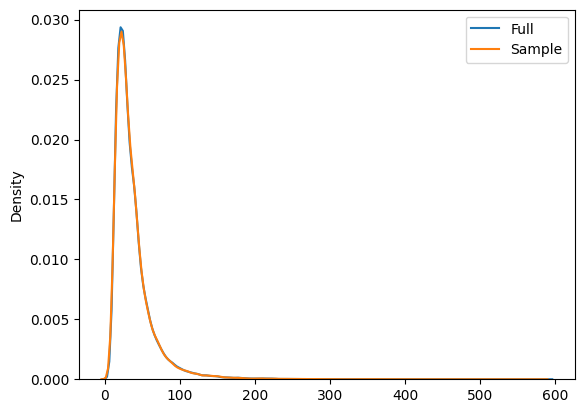

In [7]:
# 3 Case duration
import seaborn as sns

def case_duration(df):

    tmp = (
        df.groupby(
            "case:concept:name"
        )
        .agg(
            start=(
                "start:timestamp",
                "min"
            ),
            end=(
                "time:timestamp",
                "max"
            )
        )
    )

    return (
        (
            pd.to_datetime(tmp["end"])
            -
            pd.to_datetime(tmp["start"])
        )
        .dt.total_seconds()
        / 60
    )

full_dur = case_duration(full_df)
sample_dur = case_duration(sample_df)

sns.kdeplot(
    full_dur,
    label="Full"
)

sns.kdeplot(
    sample_dur,
    label="Sample"
)

plt.legend()
plt.show()

In [8]:
#4 Process Type Distribution
full_cases = (
    full_df.groupby(
        "case:concept:name"
    )
    .first()
)

sample_cases = (
    sample_df.groupby(
        "case:concept:name"
    )
    .first()
)

pd.concat(
    [
        full_cases[
            "process_flow_type"
        ]
        .value_counts(
            normalize=True
        )
        .rename("Full"),

        sample_cases[
            "process_flow_type"
        ]
        .value_counts(
            normalize=True
        )
        .rename("Sample")
    ],
    axis=1
)

,Full,Sample
receive,0.496727,0.493800
mixed,0.251833,0.253633
delivery,0.251439,0.252567


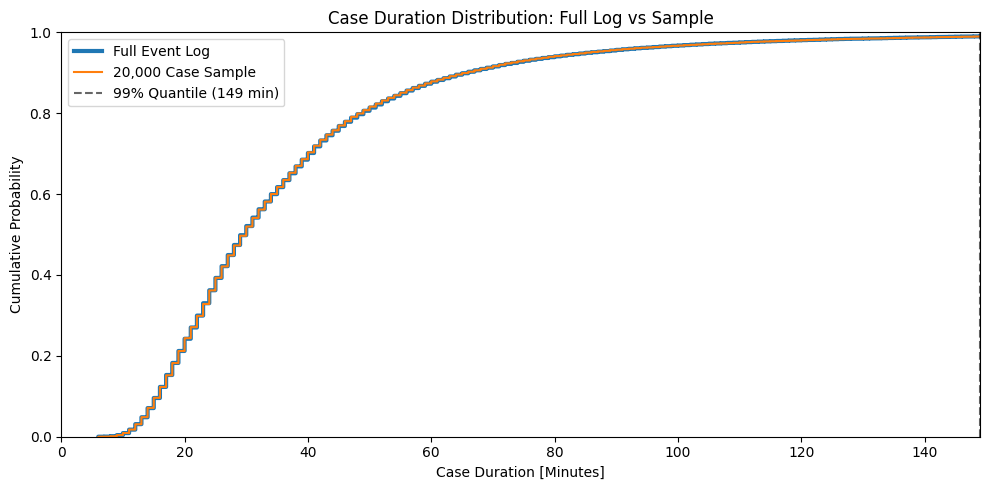

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# LOAD
# =====================================================

full_df = pd.read_csv(
    "../data/processed/CTB/s5_eventlog_one_block_target_features.csv"
)

sample_df = pd.read_csv(
    "../data/processed/CTB/sampled_real_eventlogs/s5_sample_30.000_eventlog_one_block_target_features.csv"
)

full_log = full_df
sample_log = sample_df

# =====================================================
# TIMESTAMPS
# =====================================================

for df in [full_log, sample_log]:

    for col in [
        "start:timestamp",
        "time:timestamp"
    ]:

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

# =====================================================
# CASE DURATION
# =====================================================

def case_duration(df):

    tmp = (
        df.groupby("case:concept:name")
        .agg(
            start=("start:timestamp","min"),
            end=("time:timestamp","max")
        )
    )

    return (
        (
            tmp["end"]
            -
            tmp["start"]
        )
        .dt.total_seconds()
        / 60
    )

full_duration = case_duration(full_log)

sample_duration = case_duration(sample_log)

cutoff = full_duration.quantile(0.99)

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(10,5))

sns.ecdfplot(
    full_duration,
    label="Full Event Log",
    linewidth=3
)

sns.ecdfplot(
    sample_duration,
    label="20,000 Case Sample"
)

plt.axvline(
    cutoff,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"99% Quantile ({cutoff:.0f} min)"
)

plt.xlim(0, cutoff)

plt.title(
    "Case Duration Distribution: Full Log vs Sample"
)

plt.xlabel(
    "Case Duration [Minutes]"
)

plt.ylabel(
    "Cumulative Probability"
)

plt.legend()

plt.tight_layout()

plt.show()

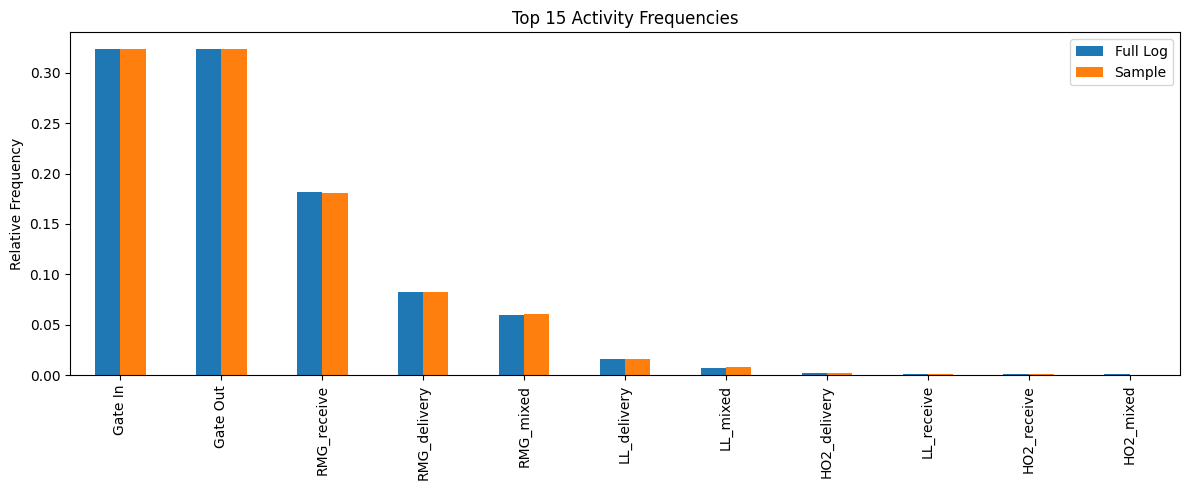

In [11]:
# =====================================================
# ACTIVITY FREQUENCIES
# =====================================================

full_freq = (
    full_log["concept:name"]
    .value_counts(normalize=True)
)

sample_freq = (
    sample_log["concept:name"]
    .value_counts(normalize=True)
)

compare = pd.concat(
    [
        full_freq.rename("Full Log"),
        sample_freq.rename("Sample")
    ],
    axis=1
).fillna(0)

compare = compare.sort_values(
    "Full Log",
    ascending=False
)

compare.head(15).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top 15 Activity Frequencies"
)

plt.ylabel(
    "Relative Frequency"
)

plt.xlabel("")

plt.tight_layout()

plt.show()

In [12]:
summary = pd.DataFrame({

    "Metric": [

        "Cases",
        "Events",
        "Activities",
        "Variants"

    ],

    "Full Log": [

        full_log["case:concept:name"].nunique(),

        len(full_log),

        full_log["concept:name"].nunique(),

        full_log.groupby(
            "case:concept:name"
        )["concept:name"]
        .agg(tuple)
        .nunique()

    ],

    "Sample": [

        sample_log["case:concept:name"].nunique(),

        len(sample_log),

        sample_log["concept:name"].nunique(),

        sample_log.groupby(
            "case:concept:name"
        )["concept:name"]
        .agg(tuple)
        .nunique()

    ]

})

print(
    summary.to_string(index=False)
)

    Metric  Full Log  Sample
     Cases     65996   30000
    Events    203661   92570
Activities        11      11
  Variants        48      38
